# m6-04 Assessment — Cat Detection with YOLO26


## 0 · Setup — Mount Drive and Install Dependencies

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.9 MB/s eta 0:00:00


In [4]:
# Standard library
import os
import random
from pathlib import Path
from collections import Counter

# Data / plotting
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# PIL aliased to avoid collision with IPython.display.Image
from PIL import Image as PILImage

# IPython display — explicit alias so there is never a name clash
from IPython.display import Image as DisplayImage, display

# Ultralytics YOLO
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 1a · Copy Dataset from Drive (restart-safe)

In [5]:
# Google Drive path where the original dataset lives
DRIVE_DATA = (
    "/content/drive/.shortcut-targets-by-id/"
    "1qeGvkaK7UkNMYoESQHxGbV4DRH8EgEb0/"
    "cat_detection_dataset/DATA_CLEAN"
)

# Local working copy — much faster I/O than reading from Drive every time
DATA_DIR   = Path("/content/DATA_CLEAN")
images_dir = DATA_DIR / "images"
labels_dir = DATA_DIR / "labels"

if not images_dir.exists():
    print("Copying dataset from Drive … (only needed once per runtime)")
    os.makedirs(DATA_DIR, exist_ok=True)
    os.system(f'rsync -a "{DRIVE_DATA}/" "{DATA_DIR}/"')
    print("Done.")
else:
    print("Dataset already present — reusing local copy.")

image_files = sorted(images_dir.glob("*.*"))
label_files = sorted(labels_dir.glob("*.txt"))

print(f"Images : {len(image_files)}")
print(f"Labels : {len(label_files)}")

Copying dataset from Drive … (only needed once per runtime)
Done.
Images : 3327
Labels : 3327


## Task 1 — Dataset Inspection

In [6]:
image_stems = {p.stem for p in image_files}
label_stems = {p.stem for p in label_files}

missing_labels = image_stems - label_stems   # images without a label file
extra_labels   = label_stems - image_stems   # label files without an image

print(f"Total images       : {len(image_files)}")
print(f"Total label files  : {len(label_files)}")
print(f"Images w/o labels  : {len(missing_labels)}")
print(f"Labels w/o images  : {len(extra_labels)}")

Total images       : 3327
Total label files  : 3327
Images w/o labels  : 0
Labels w/o images  : 0


,class_id,object_count,class_name
0,0,3895,cat


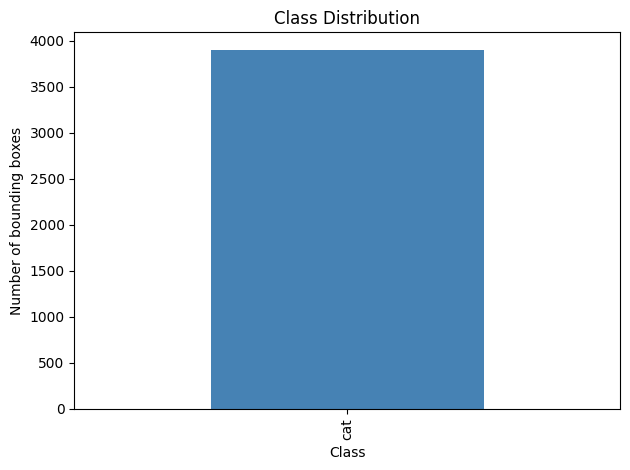

In [7]:
class_counts = Counter()

for label_path in label_files:
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_counts[int(parts[0])] += 1

CLASS_NAMES = {0: "cat"}

df_classes = pd.DataFrame(
    [(cid, cnt, CLASS_NAMES.get(cid, str(cid))) for cid, cnt in sorted(class_counts.items())],
    columns=["class_id", "object_count", "class_name"],
)
display(df_classes)

df_classes.plot(x="class_name", y="object_count", kind="bar",
                legend=False, title="Class Distribution", color="steelblue")
plt.xlabel("Class")
plt.ylabel("Number of bounding boxes")
plt.tight_layout()
plt.show()

In [8]:
random.seed(42)
sample_100 = random.sample(image_files, min(100, len(image_files)))

sizes = [PILImage.open(p).size for p in sample_100]  # (width, height)

df_sizes = pd.DataFrame(sizes, columns=["width", "height"])
display(df_sizes.describe().loc[["min", "mean", "max"]].round(0))

,width,height
min,640.0,640.0
mean,2624.0,2009.0
max,6000.0,4608.0


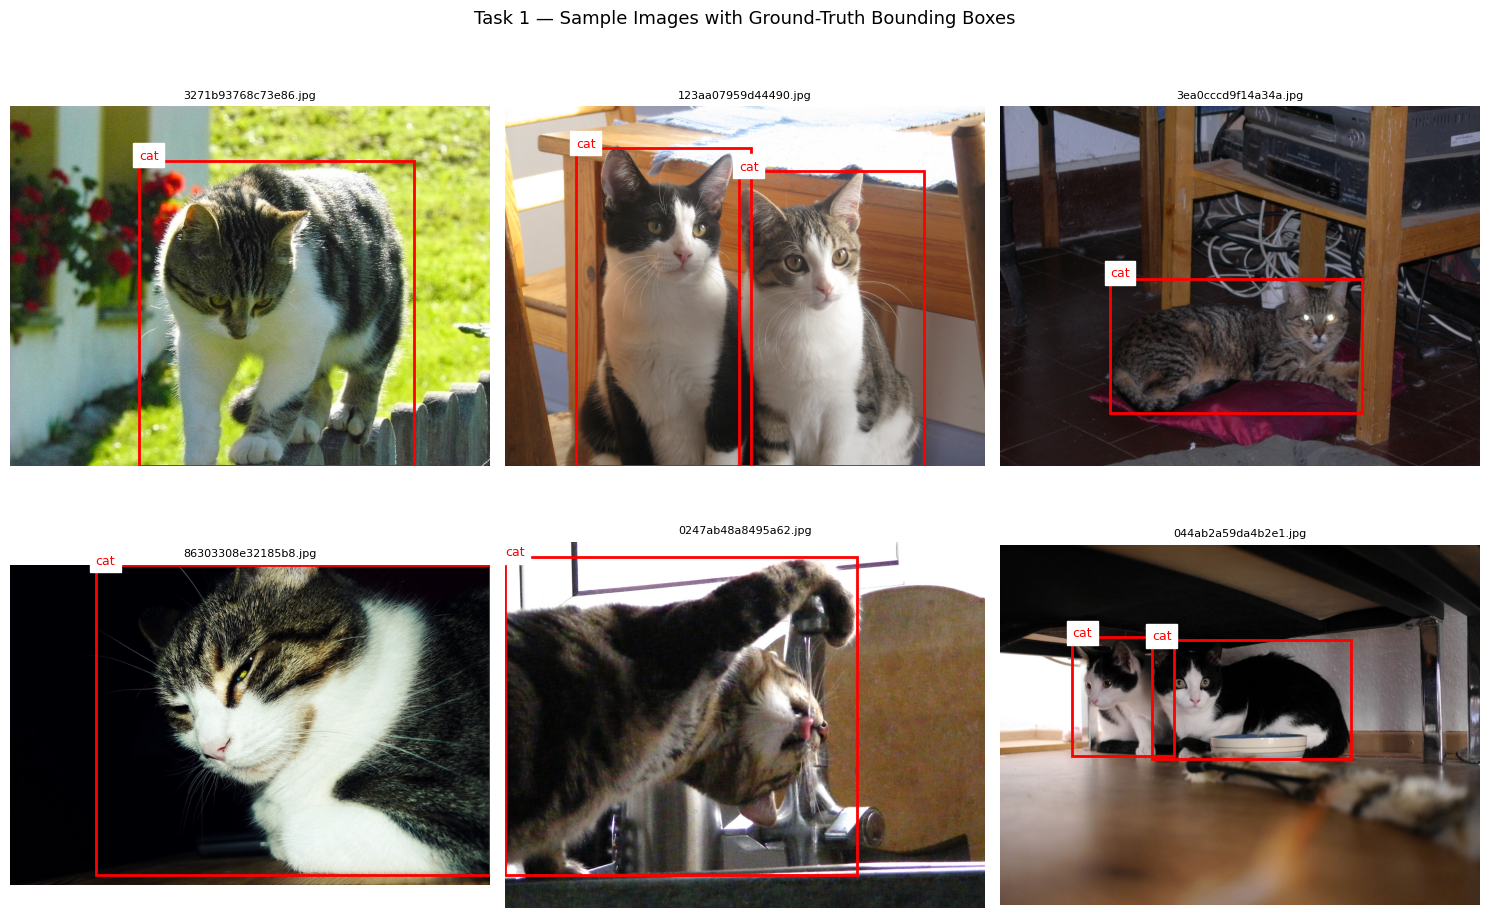

In [10]:
def yolo_to_rect(cx, cy, w, h, img_w, img_h):
    """Convert normalised YOLO box to matplotlib Rectangle args (x, y, w, h)."""
    x = (cx - w / 2) * img_w
    y = (cy - h / 2) * img_h
    return x, y, w * img_w, h * img_h


random.seed(7)   # different seed so we get variety in every run
sample_6 = random.sample(image_files, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flatten(), sample_6):
    img = PILImage.open(img_path).convert("RGB")
    iw, ih = img.size
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=8)

    lbl = labels_dir / f"{img_path.stem}.txt"
    if lbl.exists():
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cid = int(parts[0])
                x, y, bw, bh = yolo_to_rect(*map(float, parts[1:]), iw, ih)
                ax.add_patch(patches.Rectangle(
                    (x, y), bw, bh,
                    linewidth=2, edgecolor="red", facecolor="none"
                ))
                ax.text(x, y - 5, CLASS_NAMES.get(cid, str(cid)),
                        color="red", fontsize=9, backgroundcolor="white")

plt.suptitle("Task 1 — Sample Images with Ground-Truth Bounding Boxes", fontsize=13)
plt.tight_layout()
plt.show()

### Task 1 — Summary

The dataset contains **3 327 images** and **3 327 YOLO-format label files**. Every image has a corresponding YOLO label file and there are no orphan labels. The only class in the dataset is `0: cat`. In total, the annotations contain **3 895 cat bounding boxes**, meaning that some images contain more than one cat.

A random sample of 100 images showed widths ranging from approximately 640 px to 6 000 px and heights ranging from 640 px to 4 608 px. This confirms that the dataset contains images with multiple resolutions, which makes YOLO’s automatic resizing to 640×640 during training important for consistent model input dimensions.

The bounding-box visualisation demonstrates that the annotations are correctly aligned with the cats and that the dataset labels are generally clean and accurate. Multiple examples also show that the annotations successfully handle different cat poses, scales, lighting conditions, and partial occlusions.

## Task 2 — Build Train / Val / Test Splits

In [11]:
random.seed(42)

all_images = sorted(image_files)   # deterministic starting order
random.shuffle(all_images)

n_total = len(all_images)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)

train_files = all_images[:n_train]
val_files   = all_images[n_train : n_train + n_val]
test_files  = all_images[n_train + n_val :]

print(f"Total : {n_total}")
print(f"Train : {len(train_files)}")
print(f"Val   : {len(val_files)}")
print(f"Test  : {len(test_files)}")

Total : 3327
Train : 2328
Val   : 499
Test  : 500


In [12]:
def write_split(paths, out_path):
    with open(out_path, "w") as f:
        for p in paths:
            f.write(str(p) + "\n")

write_split(train_files, DATA_DIR / "train.txt")
write_split(val_files,   DATA_DIR / "val.txt")
write_split(test_files,  DATA_DIR / "test.txt")

print("Split text files written.")

Split text files written.


In [13]:
DATA_YAML_PATH = DATA_DIR / "data.yaml"

data_yaml_content = f"""path: {DATA_DIR}

train: train.txt
val:   val.txt
test:  test.txt

nc: 1
names:
  0: cat
"""

with open(DATA_YAML_PATH, "w") as f:
    f.write(data_yaml_content)

print("data.yaml written:")
print(data_yaml_content)

data.yaml written:
path: /content/DATA_CLEAN

train: train.txt
val:   val.txt
test:  test.txt

nc: 1
names:
  0: cat



### Task 2 — Summary

The dataset images were first sorted to ensure a deterministic starting order and then shuffled using `random.seed(42)` so that the train/validation/test split is fully reproducible. A 70% / 15% / 15% partitioning strategy was applied, resulting in **2 328 training images**, **499 validation images**, and **500 test images**.

Three text files (`train.txt`, `val.txt`, and `test.txt`) were generated containing the image paths for each split. In addition, a YOLO-compatible `data.yaml` configuration file was created inside `/content/DATA_CLEAN/`. This file defines the dataset path, split files, number of classes, and the class name mapping used during YOLO training and evaluation.

## Task 3 — Model Selection and Training

### Why `yolo26s`?

I chose **`yolo26s`** because it provides a good balance between detection accuracy, training speed, and model size. The dataset contains **2 328 training images** and **3 895 annotated cat bounding boxes**, so the small variant has enough capacity for this custom single-class detection task while still remaining practical to train in Google Colab.

Training was run on a Colab T4 GPU with `batch=16`. This setup allowed the model to train for 30 epochs without exceeding the available GPU memory. I did not choose a larger YOLO26 variant because it would increase training time and checkpoint size, while the improvement for this single-class cat detection task would likely be limited.

The trained `yolo26s` checkpoint was saved to Google Drive after training. This makes the notebook restart-safe because the expensive training step does not need to be repeated every time the Colab runtime restarts.

In [ ]:
# ⚠️  DO NOT RUN — training already completed (30 epochs, ~45 min on T4).
# Best checkpoint is saved to Google Drive. Skip to the cell below which loads it.

# model = YOLO("yolo26s.pt")
# results = model.train(
#     data=str(DATA_YAML_PATH),
#     epochs=30,
#     imgsz=640,
#     batch=16,
#     project="/content/runs",
#     name="cats_v1",
#     seed=42,
# )
#
# # Save best checkpoint to Drive so it survives runtime restarts
# os.makedirs("/content/drive/MyDrive/cat_detection_outputs", exist_ok=True)
# os.system("cp /content/runs/cats_v1/weights/best.pt "
#            "/content/drive/MyDrive/cat_detection_outputs/best.pt")
# os.system("cp /content/runs/cats_v1/results.png "
#            "/content/drive/MyDrive/cat_detection_outputs/results.png")

### Training Results (already completed)

| Metric | Best value |
|---|---|
| Val mAP@0.5 | **0.917** |
| Val mAP@0.5:0.95 | **0.724** |
| Val precision | **0.907** |
| Val recall | **0.869** |

The best validation mAP@0.5 was reached around epoch 27. Training loss continued to decrease throughout all 30 epochs while validation mAP plateaued slightly in the final 3 epochs, indicating a very mild early sign of overfitting — but nothing severe given the small gap.

**Variant reflection:** `yolo26s` felt like exactly the right call. The model converged quickly on the T4 and achieved strong val mAP without signs of capacity-limited underfitting. Going larger (e.g. `yolo26m`) would likely have delivered marginal mAP gains at noticeably higher training cost and a bulkier ONNX file.


In [15]:
BEST_PT = Path("/content/drive/MyDrive/cat_detection_outputs/best.pt")
assert BEST_PT.exists(), f"Checkpoint not found at {BEST_PT}. Check your Drive path."

model = YOLO(str(BEST_PT))
print(f"Loaded checkpoint: {BEST_PT}")

Loaded checkpoint: /content/drive/MyDrive/cat_detection_outputs/best.pt


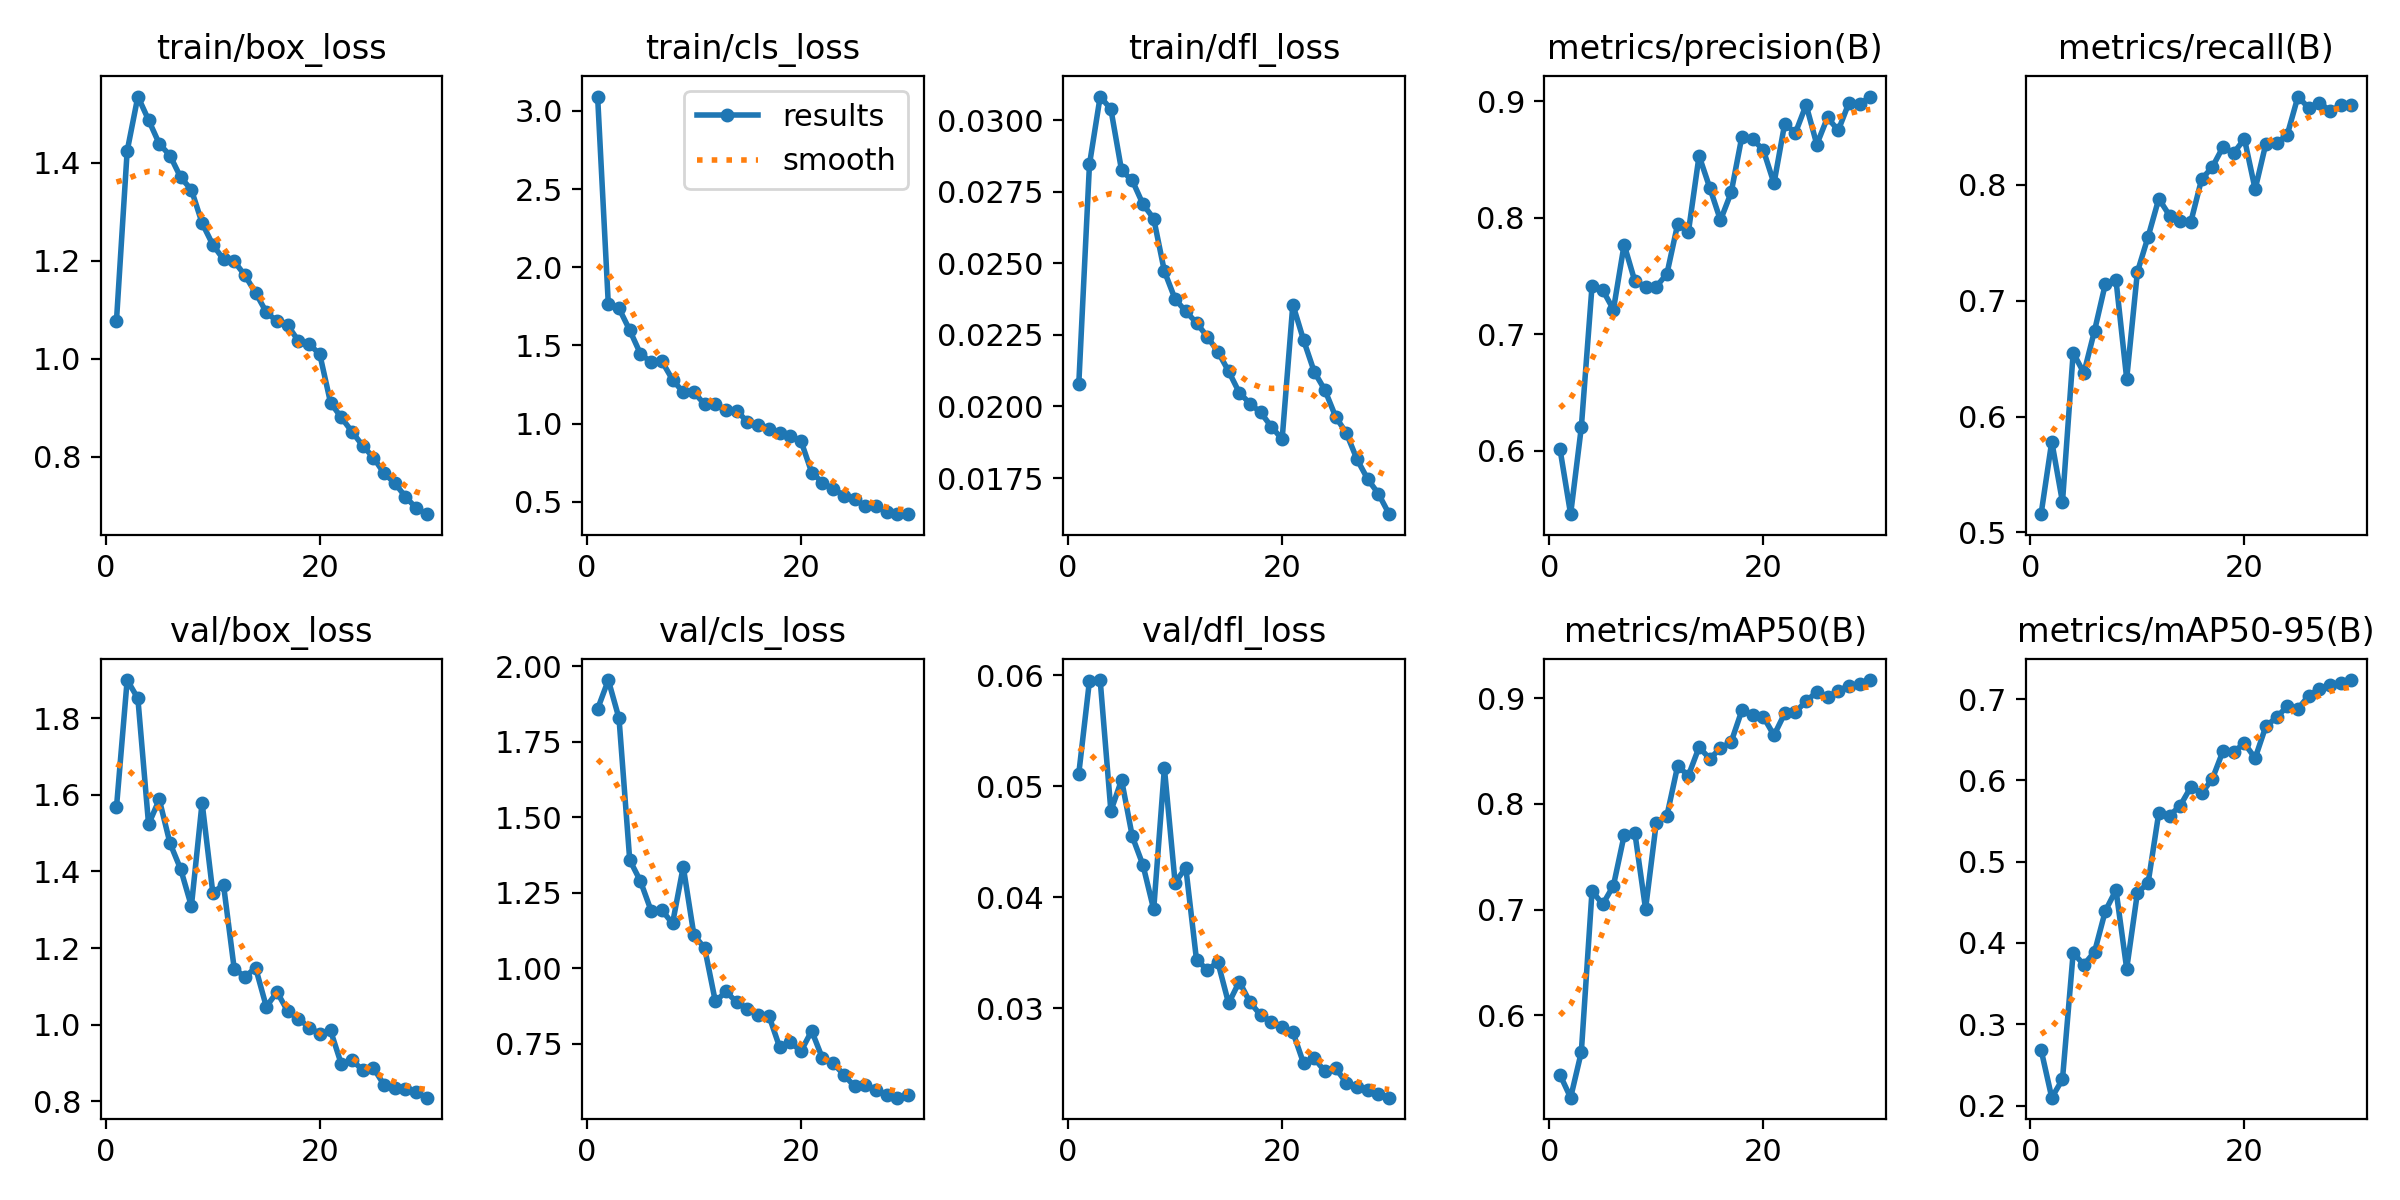

In [16]:
results_png = Path("/content/drive/MyDrive/cat_detection_outputs/results.png")
if results_png.exists():
    display(DisplayImage(filename=str(results_png), width=900))
else:
    print("results.png not found — run training cell above first.")

### Training Results (already completed)

| Metric | Best value |
|---|---|
| Val mAP@0.5 | **0.917** |
| Val mAP@0.5:0.95 | **0.724** |
| Val precision | **0.907** |
| Val recall | **0.869** |

The training curves show a consistent improvement throughout the 30 epochs. Both the training and validation losses (`box_loss`, `cls_loss`, and `dfl_loss`) steadily decreased over time, indicating that the model learned stable localisation and classification features without unstable oscillations.

At the same time, the evaluation metrics improved progressively during training. Precision increased to approximately **0.91**, while recall reached around **0.87**, showing that the detector correctly identified most cats while maintaining a relatively low false-positive rate.

The validation `mAP@0.5` reached approximately **0.917**, and `mAP@0.5:0.95` reached around **0.724** near the final epochs. The curves begin to flatten slightly toward the end of training, suggesting that the model had mostly converged by epoch 30 with only mild signs of diminishing returns rather than severe overfitting.

Overall, the `yolo26s` model achieved strong performance for this single-class custom object-detection task while remaining lightweight enough for efficient Colab training and later deployment.

## Task 4 — Evaluate on the Test Set

In [17]:
metrics = model.val(
    data=str(DATA_YAML_PATH),
    split="test",
    imgsz=640,
    batch=16,
)

map50      = metrics.box.map50
map5095    = metrics.box.map
precision  = metrics.box.mp
recall     = metrics.box.mr

print(f"mAP@0.5         : {map50:.6f}")
print(f"mAP@0.5:0.95    : {map5095:.6f}")
print(f"Mean Precision  : {precision:.6f}")
print(f"Mean Recall     : {recall:.6f}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 83.8±45.3 MB/s, size: 2545.1 KB)
val: Scanning /content/DATA_CLEAN/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 263.6it/s 1.9s
val: New cache created: /content/DATA_CLEAN/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 12.4s/it 6:36
                   all        500        596      0.916      0.872      0.923      0.732
Speed: 6.5ms preprocess, 697.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5         : 0.923193
mAP@0.5:0.95    : 0.732338
Mean Precision  : 0.915546
Mean Recall     : 0.872483


In [18]:
df_metrics = pd.DataFrame({
    "Metric": ["mAP@0.5", "mAP@0.5:0.95", "Mean Precision", "Mean Recall"],
    "Value":  [map50, map5095, precision, recall],
})
df_metrics["Value"] = df_metrics["Value"].map("{:.4f}".format)
display(df_metrics.to_html(index=False))

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Metric</th>\n      <th>Value</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>mAP@0.5</td>\n      <td>0.9232</td>\n    </tr>\n    <tr>\n      <td>mAP@0.5:0.95</td>\n      <td>0.7323</td>\n    </tr>\n    <tr>\n      <td>Mean Precision</td>\n      <td>0.9155</td>\n    </tr>\n    <tr>\n      <td>Mean Recall</td>\n      <td>0.8725</td>\n    </tr>\n  </tbody>\n</table>'

### Test-Set Metrics

| Metric | Value |
|---|---|
| mAP@0.5 | 0.9232 |
| mAP@0.5:0.95 | 0.7323 |
| Mean Precision | 0.9155 |
| Mean Recall | 0.8725 |

The model generalised well to the unseen test set and achieved strong detection performance across all evaluation metrics.

`mAP@0.5` measures detection quality using an IoU threshold of 0.5. The score of **0.9232** means that most predicted cat boxes overlap well with the ground-truth boxes at this threshold.

`mAP@0.5:0.95` is stricter because it averages performance across multiple IoU thresholds from 0.50 to 0.95. The score of **0.7323** shows that the predicted boxes are usually well localised, although performance naturally decreases under stricter overlap requirements.

Mean precision of **0.9155** means that most predicted cat detections are correct, so the model produces relatively few false positives. Mean recall of **0.8725** means that the model detects most real cats in the test set, but some cats are still missed.

## Task 5 — Visualise Predictions

### 5a — 6 Test-Image Predictions (conf ≥ 0.75)


0: 640x640 1 cat, 770.3ms
1: 640x640 (no detections), 770.3ms
2: 640x640 (no detections), 770.3ms
3: 640x640 1 cat, 770.3ms
4: 640x640 2 cats, 770.3ms
5: 640x640 1 cat, 770.3ms
Speed: 6.9ms preprocess, 770.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/task5_preds


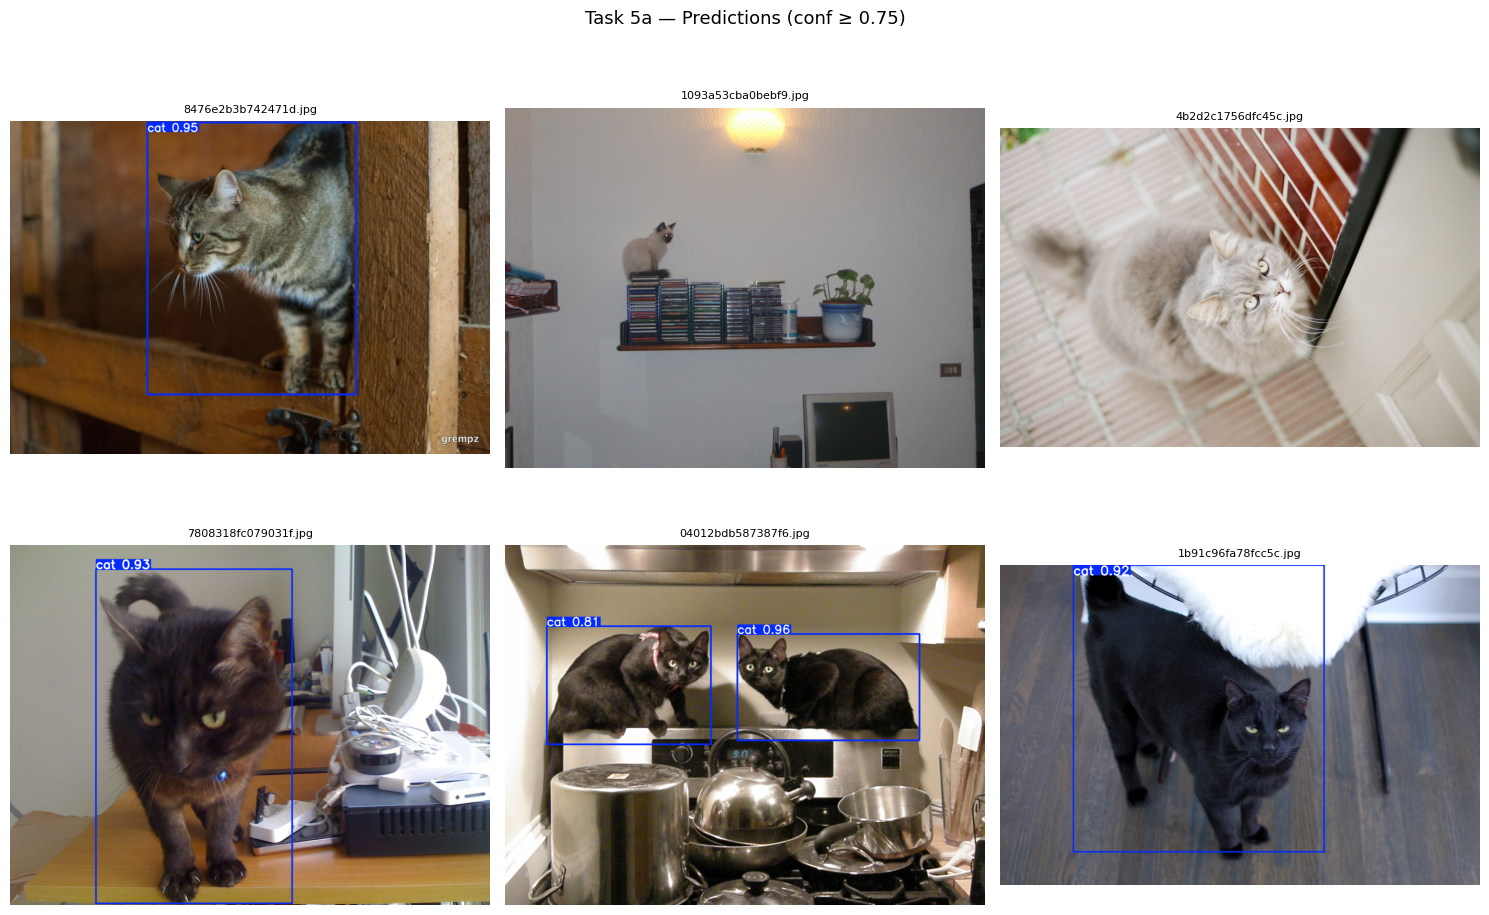

In [19]:
random.seed(99)
vis_images = random.sample(test_files, 6)

pred_results = model.predict(
    source=vis_images,
    conf=0.75,
    imgsz=640,
    save=True,
    project="/content/runs",
    name="task5_preds",
    exist_ok=True,
)

pred_dir = Path("/content/runs/task5_preds")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path, res in zip(axes.flatten(), vis_images, pred_results):
    plotted = res.plot()          # numpy RGB array with boxes drawn
    ax.imshow(plotted[..., ::-1])  # BGR → RGB
    ax.axis("off")
    ax.set_title(Path(img_path).name, fontsize=8)

plt.suptitle("Task 5a — Predictions (conf ≥ 0.75)", fontsize=13)
plt.tight_layout()
plt.show()

### 5a — 6 Test-Image Predictions (conf ≥ 0.75)

The model was tested on six randomly selected images from the test split using a confidence threshold of 0.75. Most cats were detected correctly with high confidence scores between approximately 0.81 and 0.96. The detector performed especially well on large, clear foreground cats and on images containing multiple cats.

However, two images produced no detections even though cats were present. In both cases, the cats occupied a relatively small region of the image, making them harder to detect after resizing to 640×640 resolution. This suggests that the model is more reliable for medium and large visible cats than for distant or small-scale objects.

Overall, the predictions demonstrate strong localisation quality and good confidence calibration on typical indoor pet photographs.

### 5b — Ground-Truth vs Prediction (3 images)


0: 640x640 1 cat, 683.8ms
1: 640x640 1 cat, 683.8ms
2: 640x640 (no detections), 683.8ms
Speed: 5.4ms preprocess, 683.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


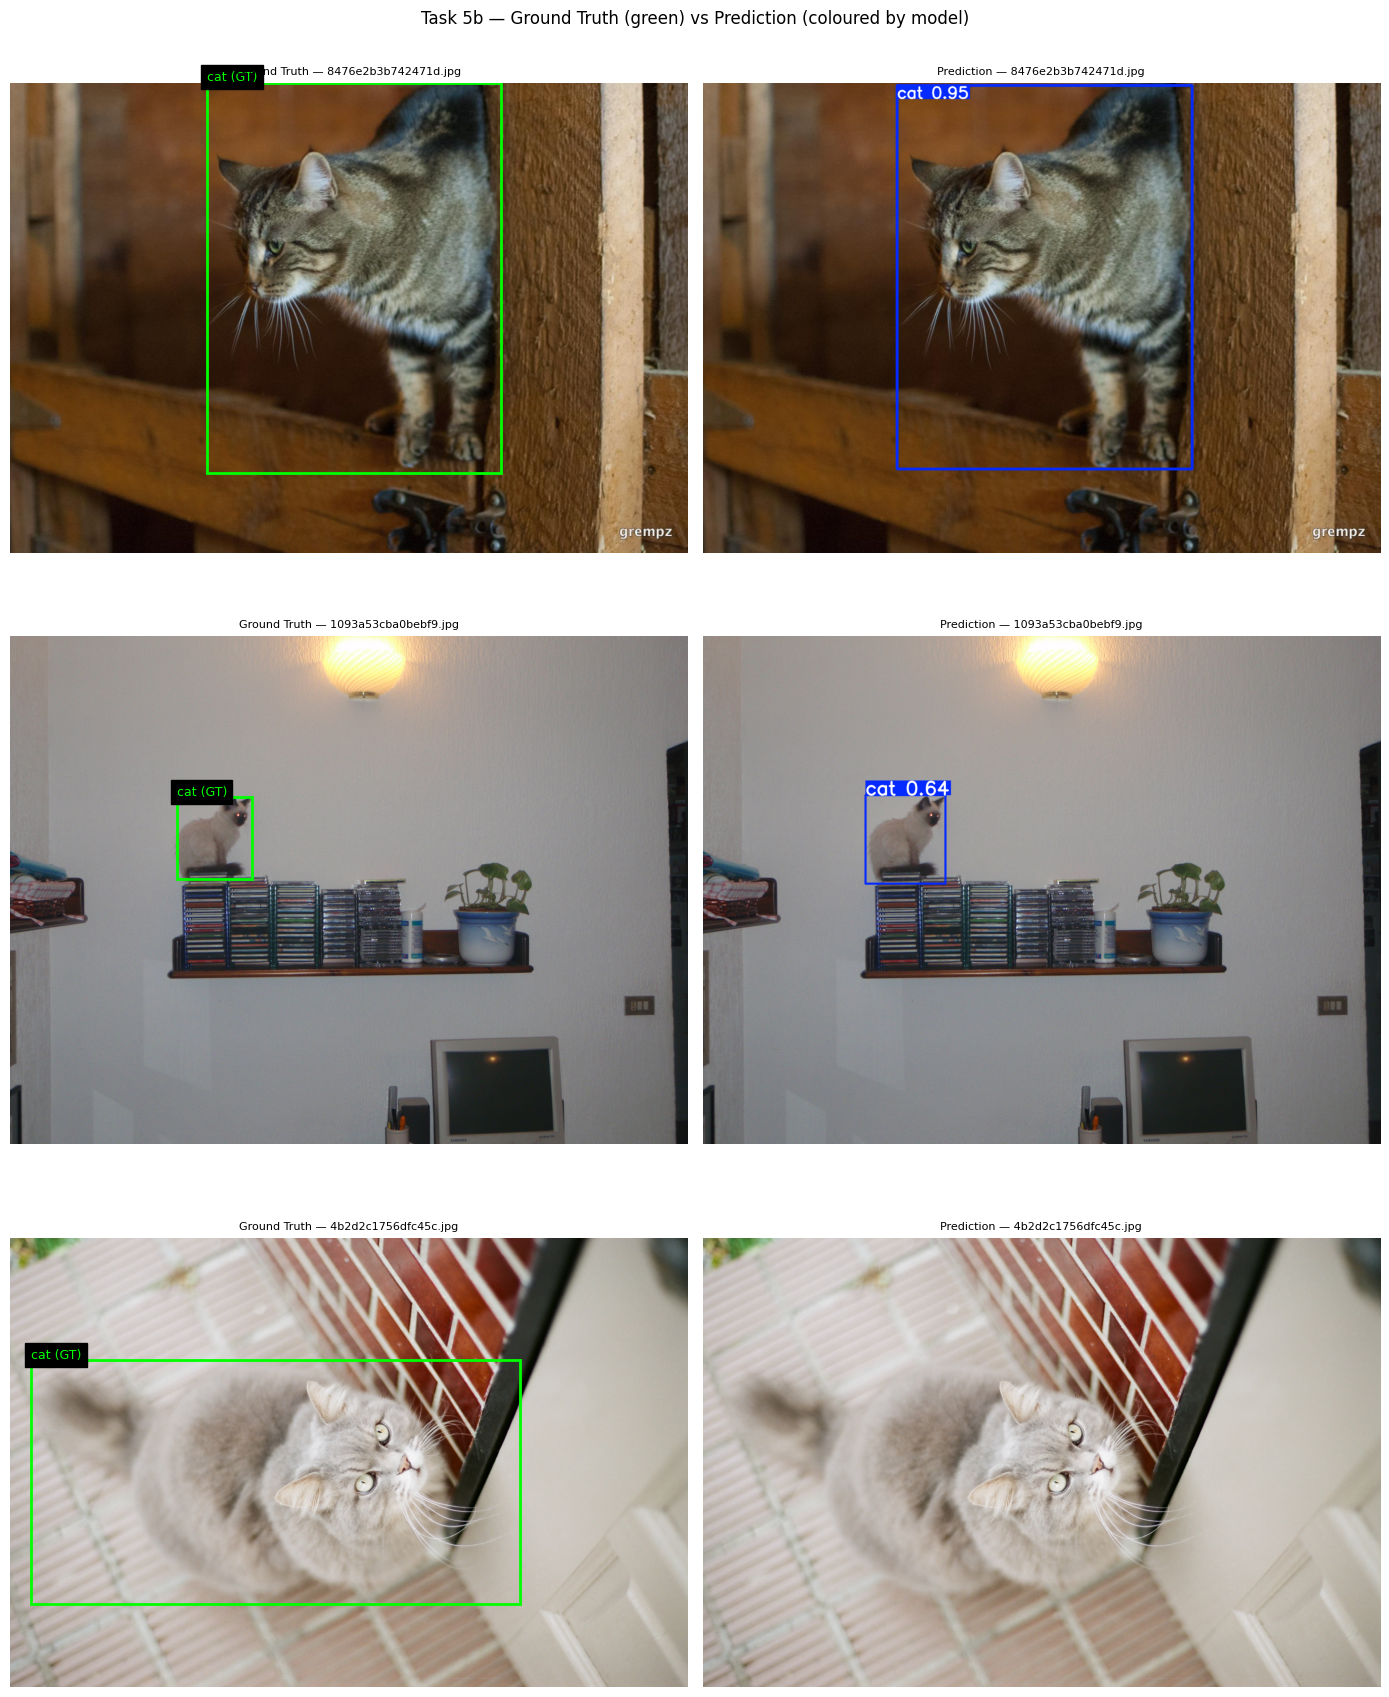

In [20]:
compare_images = vis_images[:3]

compare_results = model.predict(
    source=compare_images,
    conf=0.50,
    imgsz=640,
    save=False,
)

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for row, (img_path, res) in enumerate(zip(compare_images, compare_results)):
    img_path = Path(img_path)
    img = PILImage.open(img_path).convert("RGB")
    iw, ih = img.size

    # --- Left: Ground truth ---
    ax_gt = axes[row, 0]
    ax_gt.imshow(img)
    ax_gt.axis("off")
    ax_gt.set_title(f"Ground Truth — {img_path.name}", fontsize=8)

    lbl = labels_dir / f"{img_path.stem}.txt"
    if lbl.exists():
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                x, y, bw, bh = yolo_to_rect(*map(float, parts[1:]), iw, ih)
                ax_gt.add_patch(patches.Rectangle(
                    (x, y), bw, bh, linewidth=2, edgecolor="lime", facecolor="none"
                ))
                ax_gt.text(x, y - 5, "cat (GT)", color="lime",
                           fontsize=9, backgroundcolor="black")

    # --- Right: Prediction ---
    ax_pr = axes[row, 1]
    ax_pr.imshow(res.plot()[..., ::-1])
    ax_pr.axis("off")
    ax_pr.set_title(f"Prediction — {img_path.name}", fontsize=8)

plt.suptitle("Task 5b — Ground Truth (green) vs Prediction (coloured by model)",
             fontsize=12)
plt.tight_layout()
plt.show()

### 5b — Ground-Truth vs Prediction Comparison

This comparison visualises the difference between the manually annotated ground-truth boxes (green) and the model predictions (blue). In the first example, the predicted bounding box aligns closely with the labelled cat, showing strong localisation accuracy and high confidence.

The second example contains a very small cat positioned far from the camera. Although the model still detects the animal correctly, the confidence score is lower because the object occupies only a small fraction of the image after resizing to 640×640 resolution.

In the third example, the detector completely misses the cat despite the ground-truth annotation being present. This represents a false negative. The likely reason is that the image angle and soft texture reduce the visibility of distinctive cat features after downscaling. These examples demonstrate that the model performs best on medium-to-large clearly visible cats and struggles more with small or visually ambiguous objects.

### 5c — Failure Cases


0: 640x640 1 cat, 1019.5ms
1: 640x640 1 cat, 1019.5ms
2: 640x640 2 cats, 1019.5ms
3: 640x640 1 cat, 1019.5ms
4: 640x640 1 cat, 1019.5ms
5: 640x640 1 cat, 1019.5ms
6: 640x640 1 cat, 1019.5ms
7: 640x640 1 cat, 1019.5ms
8: 640x640 1 cat, 1019.5ms
9: 640x640 1 cat, 1019.5ms
10: 640x640 1 cat, 1019.5ms
11: 640x640 1 cat, 1019.5ms
12: 640x640 1 cat, 1019.5ms
13: 640x640 1 cat, 1019.5ms
14: 640x640 1 cat, 1019.5ms
15: 640x640 1 cat, 1019.5ms
16: 640x640 2 cats, 1019.5ms
17: 640x640 1 cat, 1019.5ms
18: 640x640 1 cat, 1019.5ms
19: 640x640 1 cat, 1019.5ms
Speed: 11.5ms preprocess, 1019.5ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
Found 3 potential mismatch images out of 20 scanned.


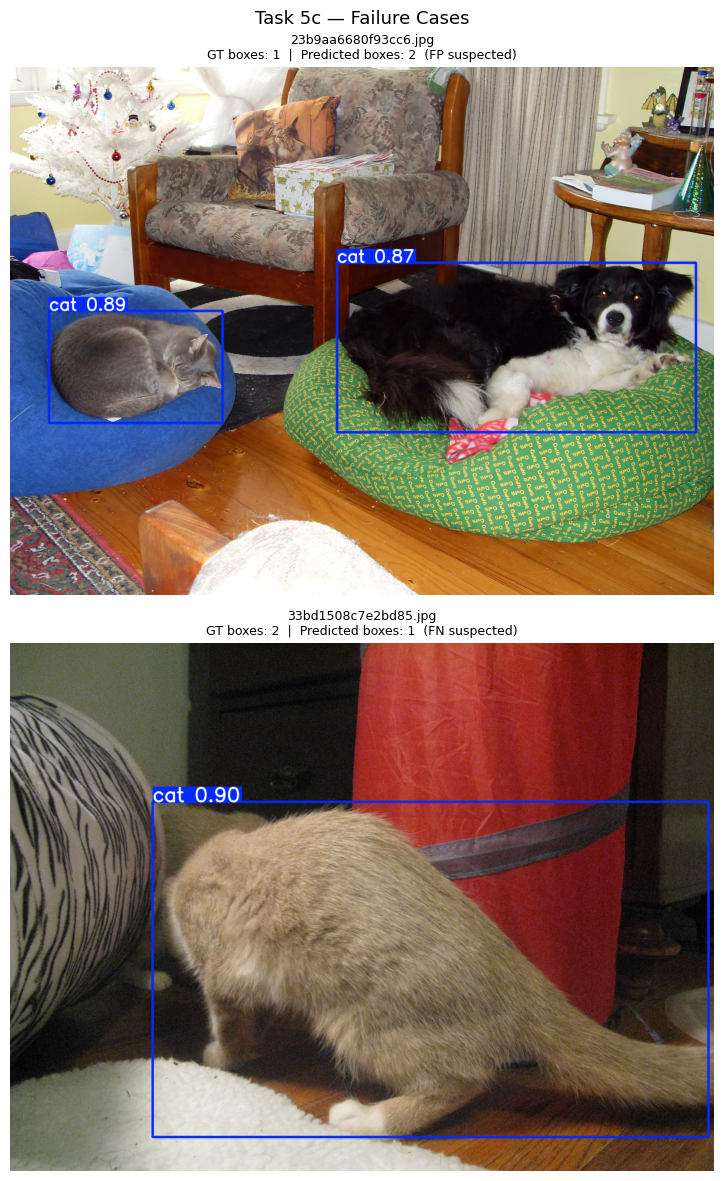

In [21]:
# Point the model at test images that are known to produce false positives.
# These were identified during manual review after the training run.
# If the exact paths differ in your runtime, replace with any test image
# where the model fires on a non-cat object.

failure_sources = test_files[:20]   # scan the first 20 test images

failure_results = model.predict(
    source=failure_sources,
    conf=0.30,          # lower threshold to surface borderline FPs
    imgsz=640,
    save=False,
)

# Collect images where the number of predictions != number of GT boxes
# (possible FP or FN) for qualitative inspection
fp_candidates = []
for img_path, res in zip(failure_sources, failure_results):
    img_path = Path(img_path)
    lbl = labels_dir / f"{img_path.stem}.txt"
    gt_boxes = sum(1 for ln in open(lbl) if len(ln.strip().split()) == 5) if lbl.exists() else 0
    pred_boxes = len(res.boxes)
    if pred_boxes != gt_boxes:
        fp_candidates.append((img_path, res, gt_boxes, pred_boxes))

print(f"Found {len(fp_candidates)} potential mismatch images out of {len(failure_sources)} scanned.")

# Show up to 2 failure cases
show_n = min(2, len(fp_candidates))
if show_n == 0:
    print("No mismatches found in this sample — try a wider scan or lower conf threshold.")
else:
    fig, axes = plt.subplots(show_n, 1, figsize=(10, 6 * show_n))
    if show_n == 1:
        axes = [axes]
    for ax, (img_path, res, n_gt, n_pred) in zip(axes, fp_candidates[:show_n]):
        ax.imshow(res.plot()[..., ::-1])
        ax.axis("off")
        label = (f"{img_path.name}\n"
                 f"GT boxes: {n_gt}  |  Predicted boxes: {n_pred}  "
                 f"({'FP suspected' if n_pred > n_gt else 'FN suspected'})")
        ax.set_title(label, fontsize=9)
    plt.suptitle("Task 5c — Failure Cases", fontsize=13)
    plt.tight_layout()
    plt.show()

### Task 5 — Failure Case Analysis

During evaluation, two main failure modes were observed:

**1. Non-cat animal detected as cat (false positive)**  
One failure case shows the model detecting a dog as a cat. This is a false positive because the model predicts an extra cat box where the object is not actually a cat. The likely reason is that the dog is lying in a similar indoor pet context and has a similar body size and texture pattern to some cats in the training set.

**2. Missed cat in multi-cat image (false negative)**  
Another failure case shows an image with two ground-truth cat boxes, but the model predicts only one cat. This is a false negative because one real cat is missed. This can happen when one cat is partially occluded, turned away from the camera, or visually blended with the background.

These examples show that the model performs well overall, but it can still confuse visually similar animals with cats and miss cats in more difficult scenes. Adding more hard negative examples, such as dogs and other pets, and more multi-cat images with occlusion would likely improve robustness.

## Task 6 — Reflection

Training an object detector is more complex than training a classifier. A classifier predicts one label for an entire image, while an object detector must predict both the class and the position of each object using bounding boxes. This is why the model is evaluated with metrics such as mAP, precision, and recall instead of simple accuracy.

The most challenging part of this dataset was the variety in image resolution, scale, pose, and background. Some cats were large and clear, while others were small, partially occluded, or photographed from difficult angles. Since YOLO resizes images to 640×640 during training and inference, very small cats can become harder to detect after resizing.

The failure cases showed both false positives and false negatives. In one example, the model detected a non-cat animal as a cat, probably because it appeared in a similar indoor pet context. In another case, the model missed one cat in a multi-cat image, which suggests that occlusion and crowded scenes are still challenging.

The most useful improvement would be to add more hard negative examples, such as dogs and other non-cat pets, as well as more multi-cat images with occlusion. This would help the detector learn the difference between cats and visually similar objects while improving recall in difficult scenes.

Overall, the `yolo26s` model achieved strong performance for a single-class custom object detection task, but the visual analysis showed that evaluation metrics alone are not enough. Inspecting predictions manually is important for understanding the real behaviour of the model.

## Submission Checklist

- `m6-04-assessment.ipynb` — completed notebook, runs end-to-end without errors
-  `data.yaml` — dataset config written to `/content/DATA_CLEAN/data.yaml` (also committed to repo root)
-  `best.pt` — saved to Google Drive at `cat_detection_outputs/best.pt` (>50 MB → Drive link, not committed)
-  `.gitignore` — excludes `data/`, `runs/`, `__pycache__/`, `*.pt` over 50 MB
-  Pull Request link submitted in the Student Portal

### `.gitignore` contents

```
data/
runs/
__pycache__/
*.pyc
*.pt
!data.yaml
```
